# Replicating Gandara et al (2024)

In [1]:
import path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.base import clone
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import statsmodels.api as sm

In [2]:
# set your directory
path = path.get_path()

## 0. Retrieve and preprocess data

In [3]:
df = pd.read_csv('./els_02_12_byf3pststu_v1_0.csv',
                 low_memory=False)

## check total sample size
print("len(df):", len(df))
print("len(df[df['BYRACE']==7]):", len(df[df['BYRACE']==7]))
print("len(df[df['BYRACE']==3]):", len(df[df['BYRACE']==3]))
print("len(df[df['BYRACE']==7] + df[df['BYRACE']==3]):", len(df[df['BYRACE']==7] + df[df['BYRACE']==3]))

len(df): 16197
len(df[df['BYRACE']==7]): 8682
len(df[df['BYRACE']==3]): 2020
len(df[df['BYRACE']==7] + df[df['BYRACE']==3]): 10702


In [4]:
data = df[['BYHOMLNG', 'BYSCENP', 'BYFCOMP', 'BYHISPOR',
           'BYGNSTAT', 'F1CTLPTN', 'BYPARED', 'BYXTRACU',
           'F2MARPAR', 'F3TZYR1GPA', 'BYSEX', 'F3TZYR1ERN', 'BYRACE', 'F1WRKHRS',
           'BYINCOME', 'F2PS1GRT', 'F2PS1SEC', 'F2PS1EEX',
           'BYURBAN', 'F1RMAT_P', 'BYTXCSTD', 'F1TXMSTD', 'BY10FLP', 'F2SWITCH',
           'BYREGION', 'F1RGPP2', 'BYSCTRL', 'F3ATTAINMENT']].copy()

## create binary outcome variable y
data['y'] = (data['F3ATTAINMENT'] >= 6).astype(int)

## drop 'F3ATTAINMENT'
data = data.drop(['F3ATTAINMENT'], axis=1)

## double check sample size
print("len(data):", len(data))

## check the number of columns of newly created data frame called data
print("len(data.columns):", len(data.columns))

len(data): 16197
len(data.columns): 28


In [5]:
## get rid of missing data (refer to the codebook for ELS2002)
data = data[~data.isin([-9, -4]).any(axis=1)]

print("len(data):", len(data))
print("len(data.columns):", len(data.columns))
print("data.columns.tolist():", data.columns.tolist())
print("data['BYRACE'].unique():", data['BYRACE'].unique())

len(data): 6575
len(data.columns): 28
data.columns.tolist(): ['BYHOMLNG', 'BYSCENP', 'BYFCOMP', 'BYHISPOR', 'BYGNSTAT', 'F1CTLPTN', 'BYPARED', 'BYXTRACU', 'F2MARPAR', 'F3TZYR1GPA', 'BYSEX', 'F3TZYR1ERN', 'BYRACE', 'F1WRKHRS', 'BYINCOME', 'F2PS1GRT', 'F2PS1SEC', 'F2PS1EEX', 'BYURBAN', 'F1RMAT_P', 'BYTXCSTD', 'F1TXMSTD', 'BY10FLP', 'F2SWITCH', 'BYREGION', 'F1RGPP2', 'BYSCTRL', 'y']
data['BYRACE'].unique(): [ 3  2  4 -8  7  6  5  1]


In [6]:
data = data[(data["BYRACE"] == 7) | (data["BYRACE"] == 3)]

print("len(data):", len(data))
print("len(data.columns):", len(data.columns))

len(data): 4808
len(data.columns): 28


In [7]:
## generating dummies for categorical data following Gandara et al. (2024)
## first select columns with categorical values to generate dummy variables
dummies = data[['BYHOMLNG', 'BYSCENP', 'BYFCOMP', 'BYHISPOR',
                'BYGNSTAT', 'F1CTLPTN', 'BYPARED', 'BYXTRACU',
                'F2MARPAR', 'BYSEX', 'BYRACE', 'F1WRKHRS',
                'BYINCOME', 'F2PS1GRT', 'F2PS1SEC', 'F2PS1EEX',
                'BYURBAN', 'F1RMAT_P', 'BY10FLP', 'F2SWITCH',
                'BYREGION', 'F1RGPP2', 'BYSCTRL']].copy()

print("len(dummies.columns):", len(dummies.columns))

## we generate dummy columns using the data frame called dummies
data_dummies = pd.get_dummies(dummies.astype(str)).astype(int)

## we select non-categorical columns to merge horizontally later
data_s = data[['F3TZYR1GPA', 'F3TZYR1ERN', 'BYTXCSTD', 'F1TXMSTD', 'y']].copy()

data_f = pd.concat([data_s, data_dummies], axis=1)

## checking for any mistakes until now
print("len(data_dummies):", len(data_dummies))
print("len(data_dummies.columns.tolist()):", len(data_dummies.columns.tolist()))
print("len(dummies.columns) + len(data_s.columns):", len(dummies.columns) + len(data_s.columns))
print("len(data_f):", len(data_f))
print("len(data_f.columns):", len(data_f.columns))

len(dummies.columns): 23
len(data_dummies): 4808
len(data_dummies.columns.tolist()): 149
len(dummies.columns) + len(data_s.columns): 28
len(data_f): 4808
len(data_f.columns): 154


In [8]:
cols = [col for col in data_f.columns if col.startswith('BYRACE')]
print("cols:", cols)

cols: ['BYRACE_3', 'BYRACE_7']


In [9]:
data_f = data_f.rename(columns={'BYRACE_7': 'White', 'BYRACE_3': 'Black'})
print("sum(White):", sum(data_f['White'])) #4,151
print("sum(Black):", sum(data_f['Black'])) #657
print("sum(White) + sum(Black):", sum(data_f['White'] + data_f['Black'])) #4,808
print(len(data_f))

test = data_f[['White', 'Black']].copy()
test['sum'] = test['White'] + test['Black']
print((test['sum'] != 1).any())

sum(White): 4151
sum(Black): 657
sum(White) + sum(Black): 4808
4808
False


## 0.1 Split Data

In [10]:
## Stratification using y and racial group following Gandara et al. (2024)
target_col = 'y'
X_lr = data_f.drop(columns=[target_col]).copy()
y_lr = data_f[target_col].copy()
combined_strata = (y_lr.astype(str) + "_" + X_lr['White'].astype(str)).values

idx = np.arange(len(X_lr))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=3456,
    stratify=combined_strata
)

X_white = X_lr.drop(columns=['Black']).copy()
X_black = X_lr.drop(columns=['White']).copy()

if 'Black' in X_black:
    X_black['Black'] = 1 - X_white['White']

# --- Split into train/test sets ---
Xw_tr, Xw_te = X_white.iloc[train_idx], X_white.iloc[test_idx]
Xb_tr, Xb_te = X_black.iloc[train_idx], X_black.iloc[test_idx]

# --- Corresponding labels ---
y_tr,  y_te  = y_lr.iloc[train_idx],  y_lr.iloc[test_idx]

# --- Separate label subsets for each encoding ---
yw_tr = y_tr.copy()
yw_te = y_te.copy()
yb_tr = y_tr.copy()
yb_te = y_te.copy()

print('number of White students: ', sum(Xw_te['White'] == 1))
print('number of Black students: ', sum(Xw_te['White'] == 0))
print('number of White students: ', sum(Xb_te['Black'] == 0))
print('number of Black students: ', sum(Xb_te['Black'] == 1))

number of White students:  830
number of Black students:  132
number of White students:  830
number of Black students:  132


# 1. Data Replication

## 1.1 Logistic Regression

In [11]:
# Base pipeline config
logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=0.1,
        class_weight='balanced',
        penalty='elasticnet',
        l1_ratio=0.75,
        solver='saga',
        max_iter=100000,
        tol=1e-8,
        random_state=3456,
        fit_intercept=True,
    )
)

# Make two independent copies
model_white = clone(logistic_model)
model_black = clone(logistic_model)

model_white.fit(Xw_tr, yw_tr)
model_black.fit(Xb_tr, yb_tr)

y_pred_white = model_white.predict(Xw_te)
y_pred_black = model_black.predict(Xb_te)

# # ---- Metrics (use y_te, not y_tr) ----
print("Test Accuracy (White encoding):", accuracy_score(yw_te, y_pred_white))
print("Test Accuracy (Black encoding):", accuracy_score(yb_te, y_pred_black))

Test Accuracy (White encoding): 0.7837837837837838
Test Accuracy (Black encoding): 0.7837837837837838


## 1.2 Confusion Matrix

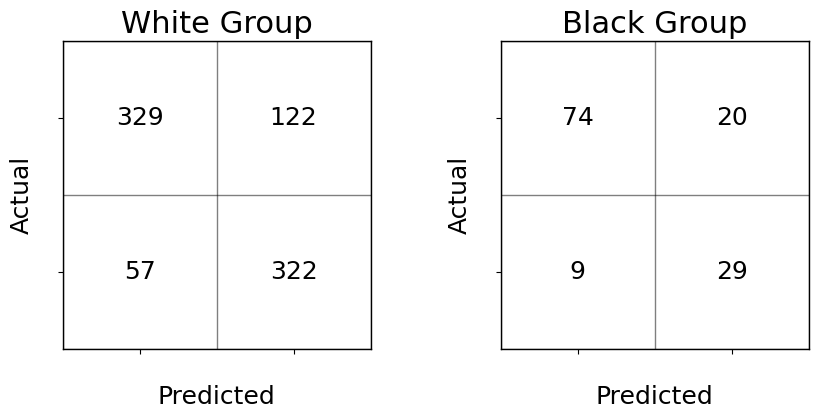

TPR (White): 0.8496042216358839
TPR (Black): 0.7631578947368421
Equal opportunity: 0.08644632689904175
FPR (White): 0.270509977827051
FPR (Black): 0.2127659574468085
Predictive equality: 0.05774402038024248


In [12]:
## White Encoding
# White group
mask_white = Xw_te['White'] == 1
cm_white = confusion_matrix(yw_te[mask_white], y_pred_white[mask_white])

# Black group
mask_black = Xw_te['White'] == 0
cm_black = confusion_matrix(yw_te[mask_black], y_pred_black[mask_black])

def plot_cm(ax, cm, title):
    ax.set_facecolor('white')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    # Draw grid
    ax.set_xticks(np.arange(-0.5, cm.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, cm.shape[0], 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # White background
    ax.imshow(np.ones_like(cm), cmap="gray", vmin=0, vmax=1)

    # Numbers in cells
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, str(val), ha="center", va="center", fontsize=18, color="black")

    # Labels
    ax.set_title(title, fontsize=22, color="black")
    ax.set_xlabel("Predicted", fontsize=18, color="black")
    ax.set_ylabel("Actual", fontsize=18, color="black")
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    ax.tick_params(axis='both', which='major', labelsize=15, color="black")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_cm(axes[0], cm_white, "White Group")
plot_cm(axes[1], cm_black, "Black Group")

plt.subplots_adjust(wspace=0.3)

fig.patch.set_facecolor('white')

plt.savefig(
    "./Figures/confusion_matrix_whiteEncodingLogit.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

#### Equal opportunity
def tpr_from_cm(cm):
    TP = cm[1,1]
    FN = cm[1,0]
    return TP / (TP + FN) if (TP+FN) > 0 else 0.0

# White group TPR
tpr_white = tpr_from_cm(cm_white)

# Black group TPR
tpr_black = tpr_from_cm(cm_black)

print("TPR (White):", tpr_white)
print("TPR (Black):", tpr_black)
print("Equal opportunity:", tpr_white - tpr_black)

#### Predictive equality
def fpr_from_cm(cm):
    FP = cm[0,1]
    TN = cm[0,0]
    return FP / (FP + TN) if (FP+TN) > 0 else 0.0

# White group FPR
fpr_white = fpr_from_cm(cm_white)

# Black group TPR
fpr_black = fpr_from_cm(cm_black)

print("FPR (White):", fpr_white)
print("FPR (Black):", fpr_black)
print("Predictive equality:", fpr_white - fpr_black)

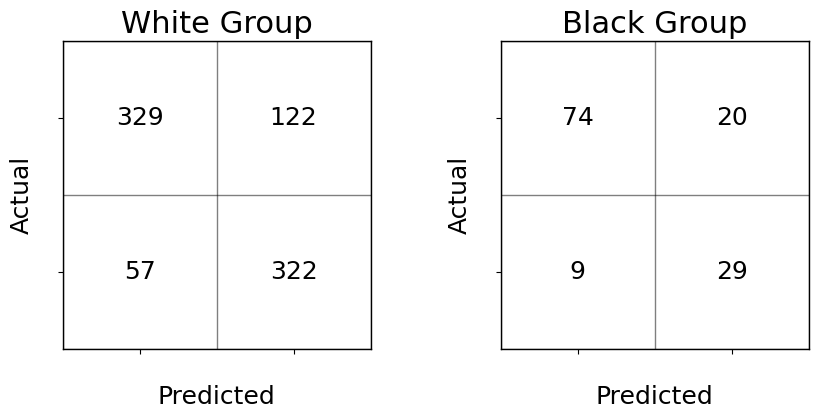

TPR (White): 0.8496042216358839
TPR (Black): 0.7631578947368421
Equal opportunity: 0.08644632689904175
FPR (White): 0.270509977827051
FPR (Black): 0.2127659574468085
Predictive equality: 0.05774402038024248
Selection rate (White): 0.5349397590361445
Selection rate (Black): 0.3712121212121212
Disparate impact (Black / White): 0.6939325689325689
80% rule violated? (DI < 0.8): True
Selection rate difference (White - Black): 0.16372763782402333


In [13]:
## Black Encoding
# White group
mask_white = Xb_te['Black'] == 0
cm_white = confusion_matrix(yb_te[mask_white], y_pred_white[mask_white])

# Black group
mask_black = Xb_te['Black'] == 1
cm_black = confusion_matrix(yb_te[mask_black], y_pred_black[mask_black])

def plot_cm(ax, cm, title):
    ax.set_facecolor('white')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    # Draw grid
    ax.set_xticks(np.arange(-0.5, cm.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, cm.shape[0], 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # White background
    ax.imshow(np.ones_like(cm), cmap="gray", vmin=0, vmax=1)

    # Numbers in cells
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, str(val), ha="center", va="center", fontsize=18, color="black")

    # Labels
    ax.set_title(title, fontsize=22, color="black")
    ax.set_xlabel("Predicted", fontsize=18, color="black")
    ax.set_ylabel("Actual", fontsize=18, color="black")
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    ax.tick_params(axis='both', which='major', labelsize=15, color="black")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_cm(axes[0], cm_white, "White Group")
plot_cm(axes[1], cm_black, "Black Group")

plt.subplots_adjust(wspace=0.3)

fig.patch.set_facecolor('white')

plt.savefig(
    "./Figures/confusion_matrix_blackEncodingLogit.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

#### Equal opportunity
def tpr_from_cm(cm):
    TP = cm[1,1]
    FN = cm[1,0]
    return TP / (TP + FN) if (TP+FN) > 0 else 0.0

# White group TPR
tpr_white = tpr_from_cm(cm_white)

# Black group TPR
tpr_black = tpr_from_cm(cm_black)

print("TPR (White):", tpr_white)
print("TPR (Black):", tpr_black)
print("Equal opportunity:", tpr_white - tpr_black)

#### Predictive equality
def fpr_from_cm(cm):
    FP = cm[0,1]
    TN = cm[0,0]
    return FP / (FP + TN) if (FP+TN) > 0 else 0.0

# White group FPR
fpr_white = fpr_from_cm(cm_white)

# Black group TPR
fpr_black = fpr_from_cm(cm_black)

print("FPR (White):", fpr_white)
print("FPR (Black):", fpr_black)
print("Predictive equality:", fpr_white - fpr_black)

#### Disparate impact (selection rate ratio)
def selection_rate(y_pred):
    # P(ŷ = 1)
    y_pred = np.asarray(y_pred)
    return np.mean(y_pred == 1)

# Selection rates by group
sr_white = selection_rate(y_pred_white[mask_white])  # P(ŷ=1 | White)
sr_black = selection_rate(y_pred_black[mask_black])  # P(ŷ=1 | Black)

# Disparate impact ratio: unprivileged / privileged
di = sr_black / sr_white if sr_white > 0 else np.nan

print("Selection rate (White):", sr_white)
print("Selection rate (Black):", sr_black)
print("Disparate impact (Black / White):", di)

# Optional: 80% rule flag (commonly used heuristic)
print("80% rule violated? (DI < 0.8):", di < 0.8)

# Optional: also report the selection-rate difference (sometimes reported alongside DI)
print("Selection rate difference (White - Black):", sr_white - sr_black)


## 1.3 Linear Regression for Causal Inference

In [14]:
## Linear Regression
# Define predictors and outcome
X_lr1 = Xw_te['White']
X_lr2 = pd.concat([Xw_te['White'], yw_te], axis=1)
y_hat_lr = y_pred_white

# Add intercept
X_lr1 = sm.add_constant(X_lr1)
X_lr2 = sm.add_constant(X_lr2)

# Fit logistic regression
linear_model_lr1 = sm.OLS(y_hat_lr, X_lr1).fit()
linear_model_lr2 = sm.OLS(y_hat_lr, X_lr2).fit()

# Show regression results
print(linear_model_lr1.summary2())
print(linear_model_lr2.summary2())

# Odds ratios (exponentiated coefficients)
print("Odds ratios:\n", np.exp(linear_model_lr1.params))
print("Odds ratios:\n", np.exp(linear_model_lr2.params))

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.012    
Dependent Variable: y                AIC:                1387.5259
Date:               2026-05-09 01:13 BIC:                1397.2639
No. Observations:   962              Log-Likelihood:     -691.76  
Df Model:           1                F-statistic:        12.35    
Df Residuals:       960              Prob (F-statistic): 0.000461 
R-squared:          0.013            Scale:              0.24718  
---------------------------------------------------------------------
           Coef.     Std.Err.      t       P>|t|     [0.025    0.975]
---------------------------------------------------------------------
const      0.3712      0.0433    8.5782    0.0000    0.2863    0.4561
White      0.1637      0.0466    3.5144    0.0005    0.0723    0.2552
------------------------------------------------------------------
Omnibus:              3755.995      Durbin-Watson:         2.074 

## 1.2 Support Vector Machine

In [15]:
svm_model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svc', SVC(
        kernel = 'linear',
        C= 0.1,
        gamma='scale',
        random_state=3456,
        max_iter=-1,
        probability=True))
])

# Make two independent copies
model_white = clone(svm_model)
model_black = clone(svm_model)

model_white.fit(Xw_tr, yw_tr)
model_black.fit(Xb_tr, yb_tr)

y_pred_white = model_white.predict(Xw_te)
y_pred_black = model_black.predict(Xb_te)

print("Test Accuracy (White encoding):", accuracy_score(yw_te, y_pred_white))
print("Test Accuracy (Black encoding):", accuracy_score(yb_te, y_pred_black))

Test Accuracy (White encoding): 0.7920997920997921
Test Accuracy (Black encoding): 0.7920997920997921


## 2.2 Confusion Matrix

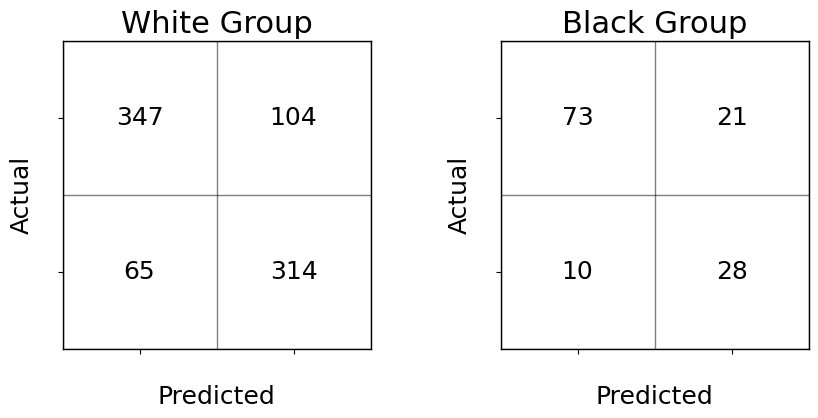

TPR (White): 0.8284960422163589
TPR (Black): 0.7368421052631579
Equal opportunity: 0.09165393695320101
FPR (White): 0.23059866962305986
FPR (Black): 0.22340425531914893
Predictive equality: 0.007194414303910934
Selection rate (White): 0.5036144578313253
Selection rate (Black): 0.3712121212121212
Disparate impact (Black / White): 0.7370958387704799
80% rule violated? (DI < 0.8): True
Selection rate difference (White - Black): 0.1324023366192041


In [16]:
## White Encoding
# White group
mask_white = Xw_te['White'] == 1
cm_white = confusion_matrix(yw_te[mask_white], y_pred_white[mask_white])

# Black group
mask_black = Xw_te['White'] == 0
cm_black = confusion_matrix(yw_te[mask_black], y_pred_white[mask_black])

def plot_cm(ax, cm, title):
    ax.set_facecolor('white')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    # Draw grid
    ax.set_xticks(np.arange(-0.5, cm.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, cm.shape[0], 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # White background
    ax.imshow(np.ones_like(cm), cmap="gray", vmin=0, vmax=1)

    # Numbers in cells
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, str(val), ha="center", va="center", fontsize=18, color="black")

    # Labels
    ax.set_title(title, fontsize=22, color="black")
    ax.set_xlabel("Predicted", fontsize=18, color="black")
    ax.set_ylabel("Actual", fontsize=18, color="black")
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    ax.tick_params(axis='both', which='major', labelsize=15, color="black")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_cm(axes[0], cm_white, "White Group")
plot_cm(axes[1], cm_black, "Black Group")

plt.subplots_adjust(wspace=0.3)

fig.patch.set_facecolor('white')

plt.savefig(
    "./Figures/confusion_matrix_whiteEncodingSVM.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

#### Equal opportunity
def tpr_from_cm(cm):
    TP = cm[1,1]
    FN = cm[1,0]
    return TP / (TP + FN) if (TP+FN) > 0 else 0.0

# White group TPR
tpr_white = tpr_from_cm(cm_white)

# Black group TPR
tpr_black = tpr_from_cm(cm_black)

print("TPR (White):", tpr_white)
print("TPR (Black):", tpr_black)
print("Equal opportunity:", tpr_white - tpr_black)

#### Predictive equality
def fpr_from_cm(cm):
    FP = cm[0,1]
    TN = cm[0,0]
    return FP / (FP + TN) if (FP+TN) > 0 else 0.0

# White group FPR
fpr_white = fpr_from_cm(cm_white)

# Black group TPR
fpr_black = fpr_from_cm(cm_black)

print("FPR (White):", fpr_white)
print("FPR (Black):", fpr_black)
print("Predictive equality:", fpr_white - fpr_black)

#### Disparate impact (selection rate ratio)
def selection_rate(y_pred):
    # P(ŷ = 1)
    y_pred = np.asarray(y_pred)
    return np.mean(y_pred == 1)

# Selection rates by group
sr_white = selection_rate(y_pred_white[mask_white])  # P(ŷ=1 | White)
sr_black = selection_rate(y_pred_black[mask_black])  # P(ŷ=1 | Black)

# Disparate impact ratio: unprivileged / privileged
di = sr_black / sr_white if sr_white > 0 else np.nan

print("Selection rate (White):", sr_white)
print("Selection rate (Black):", sr_black)
print("Disparate impact (Black / White):", di)

# Optional: 80% rule flag (commonly used heuristic)
print("80% rule violated? (DI < 0.8):", di < 0.8)

# Optional: also report the selection-rate difference (sometimes reported alongside DI)
print("Selection rate difference (White - Black):", sr_white - sr_black)


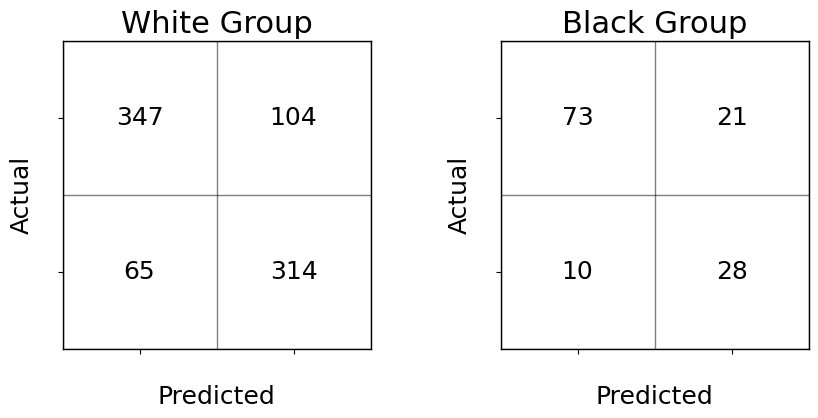

TPR (White): 0.8284960422163589
TPR (Black): 0.7368421052631579
Equal opportunity: 0.09165393695320101
FPR (White): 0.23059866962305986
FPR (Black): 0.22340425531914893
Predictive equality: 0.007194414303910934
Selection rate (White): 0.5036144578313253
Selection rate (Black): 0.3712121212121212
Disparate impact (Black / White): 0.7370958387704799
80% rule violated? (DI < 0.8): True
Selection rate difference (White - Black): 0.1324023366192041


In [17]:
## Black Encoding
# White group
mask_white = Xb_te['Black'] == 0
cm_white = confusion_matrix(yb_te[mask_white], y_pred_black[mask_white])

# Black group
mask_black = Xb_te['Black'] == 1
cm_black = confusion_matrix(yb_te[mask_black], y_pred_black[mask_black])

def plot_cm(ax, cm, title):
    ax.set_facecolor('white')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    # Draw grid
    ax.set_xticks(np.arange(-0.5, cm.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, cm.shape[0], 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # White background
    ax.imshow(np.ones_like(cm), cmap="gray", vmin=0, vmax=1)

    # Numbers in cells
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, str(val), ha="center", va="center", fontsize=18, color="black")

    # Labels
    ax.set_title(title, fontsize=22, color="black")
    ax.set_xlabel("Predicted", fontsize=18, color="black")
    ax.set_ylabel("Actual", fontsize=18, color="black")
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    ax.tick_params(axis='both', which='major', labelsize=15, color="black")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_cm(axes[0], cm_white, "White Group")
plot_cm(axes[1], cm_black, "Black Group")

plt.subplots_adjust(wspace=0.3)

fig.patch.set_facecolor('white')

plt.savefig(
    "./Figures/confusion_matrix_blackEncodingSVM.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

#### Equal opportunity
def tpr_from_cm(cm):
    TP = cm[1,1]
    FN = cm[1,0]
    return TP / (TP + FN) if (TP+FN) > 0 else 0.0

# White group TPR
tpr_white = tpr_from_cm(cm_white)

# Black group TPR
tpr_black = tpr_from_cm(cm_black)

print("TPR (White):", tpr_white)
print("TPR (Black):", tpr_black)
print("Equal opportunity:", tpr_white - tpr_black)

#### Predictive equality
def fpr_from_cm(cm):
    FP = cm[0,1]
    TN = cm[0,0]
    return FP / (FP + TN) if (FP+TN) > 0 else 0.0

# White group FPR
fpr_white = fpr_from_cm(cm_white)

# Black group TPR
fpr_black = fpr_from_cm(cm_black)

print("FPR (White):", fpr_white)
print("FPR (Black):", fpr_black)
print("Predictive equality:", fpr_white - fpr_black)

#### Disparate impact (selection rate ratio)
def selection_rate(y_pred):
    # P(ŷ = 1)
    y_pred = np.asarray(y_pred)
    return np.mean(y_pred == 1)

# Selection rates by group
sr_white = selection_rate(y_pred_white[mask_white])  # P(ŷ=1 | White)
sr_black = selection_rate(y_pred_black[mask_black])  # P(ŷ=1 | Black)

# Disparate impact ratio: unprivileged / privileged
di = sr_black / sr_white if sr_white > 0 else np.nan

print("Selection rate (White):", sr_white)
print("Selection rate (Black):", sr_black)
print("Disparate impact (Black / White):", di)

# Optional: 80% rule flag (commonly used heuristic)
print("80% rule violated? (DI < 0.8):", di < 0.8)

# Optional: also report the selection-rate difference (sometimes reported alongside DI)
print("Selection rate difference (White - Black):", sr_white - sr_black)


## 2.3 Linear Regression for Causal Inference

In [18]:
## Linear Regression
# Define predictors and outcome
X_lr1 = Xw_te['White']
X_lr2 = pd.concat([Xw_te['White'], yw_te], axis=1)
y_hat_lr = y_pred_white

# Add intercept
X_lr1 = sm.add_constant(X_lr1)
X_lr2 = sm.add_constant(X_lr2)

# Fit logistic regression
linear_model_lr1 = sm.OLS(y_hat_lr, X_lr1).fit()
linear_model_lr2 = sm.OLS(y_hat_lr, X_lr2).fit()

# Show regression results
print(linear_model_lr1.summary2())
print(linear_model_lr2.summary2())

# Odds ratios (exponentiated coefficients)
print("Odds ratios:\n", np.exp(linear_model_lr1.params))
print("Odds ratios:\n", np.exp(linear_model_lr2.params))

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.007    
Dependent Variable: y                AIC:                1391.5811
Date:               2026-05-09 01:13 BIC:                1401.3191
No. Observations:   962              Log-Likelihood:     -693.79  
Df Model:           1                F-statistic:        8.043    
Df Residuals:       960              Prob (F-statistic): 0.00466  
R-squared:          0.008            Scale:              0.24823  
---------------------------------------------------------------------
           Coef.     Std.Err.      t       P>|t|     [0.025    0.975]
---------------------------------------------------------------------
const      0.3712      0.0434    8.5602    0.0000    0.2861    0.4563
White      0.1324      0.0467    2.8360    0.0047    0.0408    0.2240
------------------------------------------------------------------
Omnibus:              3714.456      Durbin-Watson:         2.036 

## 3.1 Decision Tree

In [19]:
dt_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(
        criterion='gini',
        max_depth=6,
        min_samples_split=2,
        min_samples_leaf=20,
        random_state=3456
    ))
])

# Make two independent copies
model_white = clone(dt_model)
model_black = clone(dt_model)

model_white.fit(Xw_tr, yw_tr)
model_black.fit(Xb_tr, yb_tr)

y_pred_white = model_white.predict(Xw_te)
y_pred_black = model_black.predict(Xb_te)

print("Test Accuracy (White encoding):", accuracy_score(yw_te, y_pred_white))
print("Test Accuracy (Black encoding):", accuracy_score(yb_te, y_pred_black))

Test Accuracy (White encoding): 0.7723492723492723
Test Accuracy (Black encoding): 0.7723492723492723


## 3.2 Confusion Matrix

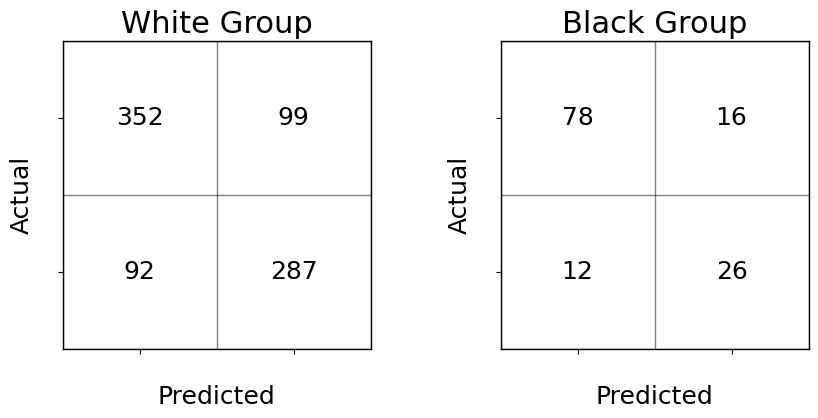

TPR (White): 0.7572559366754618
TPR (Black): 0.6842105263157895
Equal opportunity: 0.07304541035967227
FPR (White): 0.21951219512195122
FPR (Black): 0.1702127659574468
Predictive equality: 0.049299429164504416
Selection rate (White): 0.4650602409638554
Selection rate (Black): 0.3181818181818182
Disparate impact (Black / White): 0.6841733396137542
80% rule violated? (DI < 0.8): True
Selection rate difference (White - Black): 0.14687842278203722


In [20]:
## White Encoding
# White group
mask_white = Xw_te['White'] == 1
cm_white = confusion_matrix(y_te[mask_white], y_pred_white[mask_white])

# Black group
mask_black = Xw_te['White'] == 0
cm_black = confusion_matrix(y_te[mask_black], y_pred_white[mask_black])

def plot_cm(ax, cm, title):
    ax.set_facecolor('white')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    # Draw grid
    ax.set_xticks(np.arange(-0.5, cm.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, cm.shape[0], 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # White background
    ax.imshow(np.ones_like(cm), cmap="gray", vmin=0, vmax=1)

    # Numbers in cells
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, str(val), ha="center", va="center", fontsize=18, color="black")

    # Labels
    ax.set_title(title, fontsize=22, color="black")
    ax.set_xlabel("Predicted", fontsize=18, color="black")
    ax.set_ylabel("Actual", fontsize=18, color="black")
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    ax.tick_params(axis='both', which='major', labelsize=15, color="black")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_cm(axes[0], cm_white, "White Group")
plot_cm(axes[1], cm_black, "Black Group")

plt.subplots_adjust(wspace=0.3)

fig.patch.set_facecolor('white')

plt.savefig(
    "./Figures/confusion_matrix_whiteEncodingDT.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

#### Equal opportunity
def tpr_from_cm(cm):
    TP = cm[1,1]
    FN = cm[1,0]
    return TP / (TP + FN) if (TP+FN) > 0 else 0.0

# White group TPR
tpr_white = tpr_from_cm(cm_white)

# Black group TPR
tpr_black = tpr_from_cm(cm_black)

print("TPR (White):", tpr_white)
print("TPR (Black):", tpr_black)
print("Equal opportunity:", tpr_white - tpr_black)

#### Predictive equality
def fpr_from_cm(cm):
    FP = cm[0,1]
    TN = cm[0,0]
    return FP / (FP + TN) if (FP+TN) > 0 else 0.0

# White group FPR
fpr_white = fpr_from_cm(cm_white)

# Black group TPR
fpr_black = fpr_from_cm(cm_black)

print("FPR (White):", fpr_white)
print("FPR (Black):", fpr_black)
print("Predictive equality:", fpr_white - fpr_black)

#### Disparate impact (selection rate ratio)
def selection_rate(y_pred):
    # P(ŷ = 1)
    y_pred = np.asarray(y_pred)
    return np.mean(y_pred == 1)

# Selection rates by group
sr_white = selection_rate(y_pred_white[mask_white])  # P(ŷ=1 | White)
sr_black = selection_rate(y_pred_black[mask_black])  # P(ŷ=1 | Black)

# Disparate impact ratio: unprivileged / privileged
di = sr_black / sr_white if sr_white > 0 else np.nan

print("Selection rate (White):", sr_white)
print("Selection rate (Black):", sr_black)
print("Disparate impact (Black / White):", di)

# Optional: 80% rule flag (commonly used heuristic)
print("80% rule violated? (DI < 0.8):", di < 0.8)

# Optional: also report the selection-rate difference (sometimes reported alongside DI)
print("Selection rate difference (White - Black):", sr_white - sr_black)

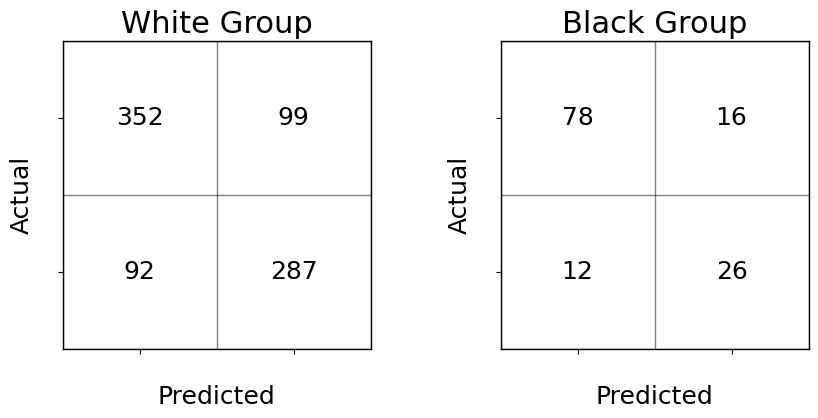

TPR (White): 0.7572559366754618
TPR (Black): 0.6842105263157895
Equal opportunity: 0.07304541035967227
FPR (White): 0.21951219512195122
FPR (Black): 0.1702127659574468
Predictive equality: 0.049299429164504416
Selection rate (White): 0.4650602409638554
Selection rate (Black): 0.3181818181818182
Disparate impact (Black / White): 0.6841733396137542
80% rule violated? (DI < 0.8): True
Selection rate difference (White - Black): 0.14687842278203722


In [21]:
## Black Encoding
# White group
mask_white = Xb_te['Black'] == 0
cm_white = confusion_matrix(y_te[mask_white], y_pred_black[mask_white])

# Black group
mask_black = Xb_te['Black'] == 1
cm_black = confusion_matrix(y_te[mask_black], y_pred_black[mask_black])

def plot_cm(ax, cm, title):
    ax.set_facecolor('white')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    # Draw grid
    ax.set_xticks(np.arange(-0.5, cm.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, cm.shape[0], 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # White background
    ax.imshow(np.ones_like(cm), cmap="gray", vmin=0, vmax=1)

    # Numbers in cells
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, str(val), ha="center", va="center", fontsize=18, color="black")

    # Labels
    ax.set_title(title, fontsize=22, color="black")
    ax.set_xlabel("Predicted", fontsize=18, color="black")
    ax.set_ylabel("Actual", fontsize=18, color="black")
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    ax.tick_params(axis='both', which='major', labelsize=15, color="black")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_cm(axes[0], cm_white, "White Group")
plot_cm(axes[1], cm_black, "Black Group")

plt.subplots_adjust(wspace=0.3)

fig.patch.set_facecolor('white')

plt.savefig(
    "./Figures/confusion_matrix_blackEncodingDT.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

#### Equal opportunity
def tpr_from_cm(cm):
    TP = cm[1,1]
    FN = cm[1,0]
    return TP / (TP + FN) if (TP+FN) > 0 else 0.0

# White group TPR
tpr_white = tpr_from_cm(cm_white)

# Black group TPR
tpr_black = tpr_from_cm(cm_black)

print("TPR (White):", tpr_white)
print("TPR (Black):", tpr_black)
print("Equal opportunity:", tpr_white - tpr_black)

#### Predictive equality
def fpr_from_cm(cm):
    FP = cm[0,1]
    TN = cm[0,0]
    return FP / (FP + TN) if (FP+TN) > 0 else 0.0

# White group FPR
fpr_white = fpr_from_cm(cm_white)

# Black group TPR
fpr_black = fpr_from_cm(cm_black)

print("FPR (White):", fpr_white)
print("FPR (Black):", fpr_black)
print("Predictive equality:", fpr_white - fpr_black)

#### Disparate impact (selection rate ratio)
def selection_rate(y_pred):
    # P(ŷ = 1)
    y_pred = np.asarray(y_pred)
    return np.mean(y_pred == 1)

# Selection rates by group
sr_white = selection_rate(y_pred_white[mask_white])  # P(ŷ=1 | White)
sr_black = selection_rate(y_pred_black[mask_black])  # P(ŷ=1 | Black)

# Disparate impact ratio: unprivileged / privileged
di = sr_black / sr_white if sr_white > 0 else np.nan

print("Selection rate (White):", sr_white)
print("Selection rate (Black):", sr_black)
print("Disparate impact (Black / White):", di)

# Optional: 80% rule flag (commonly used heuristic)
print("80% rule violated? (DI < 0.8):", di < 0.8)

# Optional: also report the selection-rate difference (sometimes reported alongside DI)
print("Selection rate difference (White - Black):", sr_white - sr_black)

## 3.3 Linear Regression for Causal Inference

In [22]:
## Linear Regression
# Define predictors and outcome
X_lr1 = Xw_te['White']
X_lr2 = pd.concat([Xw_te['White'], y_te], axis=1)
y_hat_lr = y_pred_white

# Add intercept
X_lr1 = sm.add_constant(X_lr1)
X_lr2 = sm.add_constant(X_lr2)

# Fit logistic regression
linear_model_lr1 = sm.OLS(y_hat_lr, X_lr1).fit()
linear_model_lr2 = sm.OLS(y_hat_lr, X_lr2).fit()

# Show regression results
print(linear_model_lr1.summary2())
print(linear_model_lr2.summary2())

# Odds ratios (exponentiated coefficients)
print("Odds ratios:\n", np.exp(linear_model_lr1.params))
print("Odds ratios:\n", np.exp(linear_model_lr2.params))

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.009    
Dependent Variable: y                AIC:                1378.6709
Date:               2026-05-09 01:14 BIC:                1388.4090
No. Observations:   962              Log-Likelihood:     -687.34  
Df Model:           1                F-statistic:        10.03    
Df Residuals:       960              Prob (F-statistic): 0.00159  
R-squared:          0.010            Scale:              0.24492  
---------------------------------------------------------------------
           Coef.     Std.Err.      t       P>|t|     [0.025    0.975]
---------------------------------------------------------------------
const      0.3182      0.0431    7.3867    0.0000    0.2336    0.4027
White      0.1469      0.0464    3.1673    0.0016    0.0559    0.2379
------------------------------------------------------------------
Omnibus:              3847.207      Durbin-Watson:         1.986 

## 4.1 Random Forest

In [23]:
rf_model = RandomForestClassifier(
        n_estimators=1000,
        max_features=.6,
        bootstrap=True,
        criterion='log_loss',
        max_depth=6,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=3456,
        n_jobs=-1
    )

# Make two independent copies
model_white = clone(rf_model)
model_black = clone(rf_model)

model_white.fit(Xw_tr, yw_tr)
model_black.fit(Xb_tr, yb_tr)

y_pred_white = model_white.predict(Xw_te)
y_pred_black = model_black.predict(Xb_te)

print("Test Accuracy (White encoding):", accuracy_score(yw_te, y_pred_white))
print("Test Accuracy (Black encoding):", accuracy_score(yb_te, y_pred_black))

Test Accuracy (White encoding): 0.7858627858627859
Test Accuracy (Black encoding): 0.7858627858627859


## 4.2 Confusion Matrix

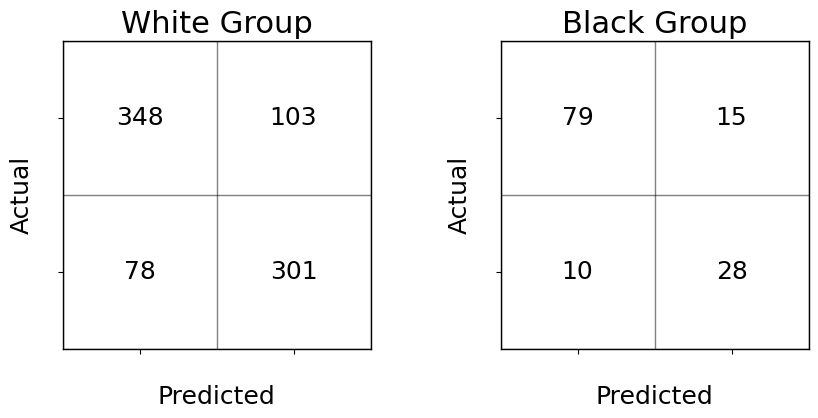

TPR (White): 0.7941952506596306
TPR (Black): 0.7368421052631579
Equal opportunity: 0.05735314539647274
FPR (White): 0.22838137472283815
FPR (Black): 0.1595744680851064
Predictive equality: 0.06880690663773176
Selection rate (White): 0.4867469879518072
Selection rate (Black): 0.32575757575757575
Disparate impact (Black / White): 0.6692544254425442
80% rule violated? (DI < 0.8): True
Selection rate difference (White - Black): 0.16098941219423146


In [24]:
## White Encoding
# White group
mask_white = Xw_te['White'] == 1
cm_white = confusion_matrix(yw_te[mask_white], y_pred_white[mask_white])

# Black group
mask_black = Xw_te['White'] == 0
cm_black = confusion_matrix(yw_te[mask_black], y_pred_white[mask_black])

def plot_cm(ax, cm, title):
    ax.set_facecolor('white')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    # Draw grid
    ax.set_xticks(np.arange(-0.5, cm.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, cm.shape[0], 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # White background
    ax.imshow(np.ones_like(cm), cmap="gray", vmin=0, vmax=1)

    # Numbers in cells
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, str(val), ha="center", va="center", fontsize=18, color="black")

    # Labels
    ax.set_title(title, fontsize=22, color="black")
    ax.set_xlabel("Predicted", fontsize=18, color="black")
    ax.set_ylabel("Actual", fontsize=18, color="black")
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    ax.tick_params(axis='both', which='major', labelsize=15, color="black")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_cm(axes[0], cm_white, "White Group")
plot_cm(axes[1], cm_black, "Black Group")

plt.subplots_adjust(wspace=0.3)

fig.patch.set_facecolor('white')

plt.savefig(
    "./Figures/confusion_matrix_whiteEncodingRF.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

#### Equal opportunity
def tpr_from_cm(cm):
    TP = cm[1,1]
    FN = cm[1,0]
    return TP / (TP + FN) if (TP+FN) > 0 else 0.0

# White group TPR
tpr_white = tpr_from_cm(cm_white)

# Black group TPR
tpr_black = tpr_from_cm(cm_black)

print("TPR (White):", tpr_white)
print("TPR (Black):", tpr_black)
print("Equal opportunity:", tpr_white - tpr_black)

#### Predictive equality
def fpr_from_cm(cm):
    FP = cm[0,1]
    TN = cm[0,0]
    return FP / (FP + TN) if (FP+TN) > 0 else 0.0

# White group FPR
fpr_white = fpr_from_cm(cm_white)

# Black group TPR
fpr_black = fpr_from_cm(cm_black)

print("FPR (White):", fpr_white)
print("FPR (Black):", fpr_black)
print("Predictive equality:", fpr_white - fpr_black)

#### Disparate impact (selection rate ratio)
def selection_rate(y_pred):
    # P(ŷ = 1)
    y_pred = np.asarray(y_pred)
    return np.mean(y_pred == 1)

# Selection rates by group
sr_white = selection_rate(y_pred_white[mask_white])  # P(ŷ=1 | White)
sr_black = selection_rate(y_pred_black[mask_black])  # P(ŷ=1 | Black)

# Disparate impact ratio: unprivileged / privileged
di = sr_black / sr_white if sr_white > 0 else np.nan

print("Selection rate (White):", sr_white)
print("Selection rate (Black):", sr_black)
print("Disparate impact (Black / White):", di)

# Optional: 80% rule flag (commonly used heuristic)
print("80% rule violated? (DI < 0.8):", di < 0.8)

# Optional: also report the selection-rate difference (sometimes reported alongside DI)
print("Selection rate difference (White - Black):", sr_white - sr_black)


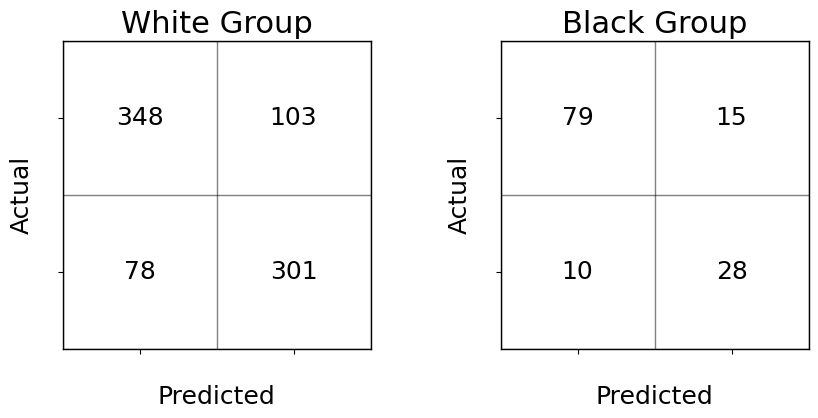

TPR (White): 0.7941952506596306
TPR (Black): 0.7368421052631579
Equal opportunity: 0.05735314539647274
FPR (White): 0.22838137472283815
FPR (Black): 0.1595744680851064
Predictive equality: 0.06880690663773176
Selection rate (White): 0.4867469879518072
Selection rate (Black): 0.32575757575757575
Disparate impact (Black / White): 0.6692544254425442
80% rule violated? (DI < 0.8): True
Selection rate difference (White - Black): 0.16098941219423146


In [25]:
## Black Encoding
# White group
mask_white = Xb_te['Black'] == 0
cm_white = confusion_matrix(yb_te[mask_white], y_pred_black[mask_white])

# Black group
mask_black = Xb_te['Black'] == 1
cm_black = confusion_matrix(yb_te[mask_black], y_pred_black[mask_black])

def plot_cm(ax, cm, title):
    ax.set_facecolor('white')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    # Draw grid
    ax.set_xticks(np.arange(-0.5, cm.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, cm.shape[0], 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # White background
    ax.imshow(np.ones_like(cm), cmap="gray", vmin=0, vmax=1)

    # Numbers in cells
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, str(val), ha="center", va="center", fontsize=18, color="black")

    # Labels
    ax.set_title(title, fontsize=22, color="black")
    ax.set_xlabel("Predicted", fontsize=18, color="black")
    ax.set_ylabel("Actual", fontsize=18, color="black")
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    ax.tick_params(axis='both', which='major', labelsize=15, color="black")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_cm(axes[0], cm_white, "White Group")
plot_cm(axes[1], cm_black, "Black Group")

plt.subplots_adjust(wspace=0.3)

fig.patch.set_facecolor('white')

plt.savefig(
    "./Figures/confusion_matrix_blackEncodingRF.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

#### Equal opportunity
def tpr_from_cm(cm):
    TP = cm[1,1]
    FN = cm[1,0]
    return TP / (TP + FN) if (TP+FN) > 0 else 0.0

# White group TPR
tpr_white = tpr_from_cm(cm_white)

# Black group TPR
tpr_black = tpr_from_cm(cm_black)

print("TPR (White):", tpr_white)
print("TPR (Black):", tpr_black)
print("Equal opportunity:", tpr_white - tpr_black)

#### Predictive equality
def fpr_from_cm(cm):
    FP = cm[0,1]
    TN = cm[0,0]
    return FP / (FP + TN) if (FP+TN) > 0 else 0.0

# White group FPR
fpr_white = fpr_from_cm(cm_white)

# Black group TPR
fpr_black = fpr_from_cm(cm_black)

print("FPR (White):", fpr_white)
print("FPR (Black):", fpr_black)
print("Predictive equality:", fpr_white - fpr_black)

#### Disparate impact (selection rate ratio)
def selection_rate(y_pred):
    # P(ŷ = 1)
    y_pred = np.asarray(y_pred)
    return np.mean(y_pred == 1)

# Selection rates by group
sr_white = selection_rate(y_pred_white[mask_white])  # P(ŷ=1 | White)
sr_black = selection_rate(y_pred_black[mask_black])  # P(ŷ=1 | Black)

# Disparate impact ratio: unprivileged / privileged
di = sr_black / sr_white if sr_white > 0 else np.nan

print("Selection rate (White):", sr_white)
print("Selection rate (Black):", sr_black)
print("Disparate impact (Black / White):", di)

# Optional: 80% rule flag (commonly used heuristic)
print("80% rule violated? (DI < 0.8):", di < 0.8)

# Optional: also report the selection-rate difference (sometimes reported alongside DI)
print("Selection rate difference (White - Black):", sr_white - sr_black)


## 4.3 Linear Regression for Causal Inference

In [26]:
## Linear Regression
# Define predictors and outcome
X_lr1 = Xw_te['White']
X_lr2 = pd.concat([Xw_te['White'], yw_te], axis=1)
y_hat_lr = y_pred_white

# Add intercept
X_lr1 = sm.add_constant(X_lr1)
X_lr2 = sm.add_constant(X_lr2)

# Fit logistic regression
linear_model_lr1 = sm.OLS(y_hat_lr, X_lr1).fit()
linear_model_lr2 = sm.OLS(y_hat_lr, X_lr2).fit()

# Show regression results
print(linear_model_lr1.summary2())
print(linear_model_lr2.summary2())

# Odds ratios (exponentiated coefficients)
print("Odds ratios:\n", np.exp(linear_model_lr1.params))
print("Odds ratios:\n", np.exp(linear_model_lr2.params))

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.011    
Dependent Variable: y                AIC:                1383.6640
Date:               2026-05-09 01:14 BIC:                1393.4020
No. Observations:   962              Log-Likelihood:     -689.83  
Df Model:           1                F-statistic:        11.99    
Df Residuals:       960              Prob (F-statistic): 0.000559 
R-squared:          0.012            Scale:              0.24619  
---------------------------------------------------------------------
           Coef.     Std.Err.      t       P>|t|     [0.025    0.975]
---------------------------------------------------------------------
const      0.3258      0.0432    7.5430    0.0000    0.2410    0.4105
White      0.1610      0.0465    3.4626    0.0006    0.0697    0.2522
------------------------------------------------------------------
Omnibus:              3789.175      Durbin-Watson:         2.085 